# 第6章 金融时间序列 · 课堂代码

> 本 notebook 与课件《Python金融数据分析 · 第6章 金融时间序列》配套。
> 内容改编自《Python金融大数据分析（第2版）》第8章。

**本章首次使用真实市场数据**：`eod_data.csv`（来源：Refinitiv Eikon，教材配套数据），
包含 2010-01 至 2018-06 共 12 个资产的日频收盘价。

**使用说明**
- 点击单元格，按 `Shift + Enter` 运行；
- 确认本章 `data/` 下有 `eod_data.csv` 文件。

## 路径准备

输入数据放在本章 `data/`，运行生成的文件放在 `outputs/`，Notebook放在 `notebooks/`。下面统一设置路径，Windows和macOS共用；可从本章notebooks目录、本章目录或课程根目录运行。

In [ ]:
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    CHAPTER = cwd.parent
elif cwd.name == "Chapter6 - 金融时间序列":
    CHAPTER = cwd
else:
    CHAPTER = cwd / "Chapter6 - 金融时间序列"
assert CHAPTER.is_dir(), "请从本章notebooks目录、本章目录或课程根目录运行"
DATA = CHAPTER / "data"
OUTPUTS = CHAPTER / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)


## 1. 真实数据登场

### 1.1 读入数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df = pd.read_csv(DATA / "eod_data.csv",    # 本章data目录
                 index_col=0,       # 第0列(日期)作索引
                 parse_dates=True)  # 解析成日期类型
df.shape          # (2216, 12)：8年半，2216个日期

(2216, 12)

In [3]:
df.columns.tolist()

['AAPL.O',
 'MSFT.O',
 'INTC.O',
 'AMZN.O',
 'GS.N',
 'SPY',
 '.SPX',
 '.VIX',
 'EUR=',
 'XAU=',
 'GDX',
 'GLD']

In [4]:
df.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4323,1096.35,NaN,NaN
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82


### 1.2 数据体检：缺失值在哪里？

不同市场的交易日不完全重合，所以表里有 `NaN`——真实数据的常态。
以 SPY（美股ETF）为准过滤日期：只研究美股交易日。

In [5]:
df.isna().sum()      # 每列缺失个数

AAPL.O    78
MSFT.O    78
INTC.O    78
AMZN.O    78
GS.N      78
SPY       78
.SPX      78
.VIX      78
EUR=       0
XAU=       5
GDX       78
GLD       78
dtype: int64

In [6]:
df = df.dropna(subset=["SPY", "AAPL.O"])  # 只保留美股交易日
df.shape             # (2138, 12)

(2138, 12)

### 1.3 先看全景：归一化价格

不同资产价格量级差异大（黄金上千、汇率1.4），直接画没法比。
除以各自首日价格再乘100：把"价格"变成"涨跌幅指数"。

<Axes: xlabel='Date'>

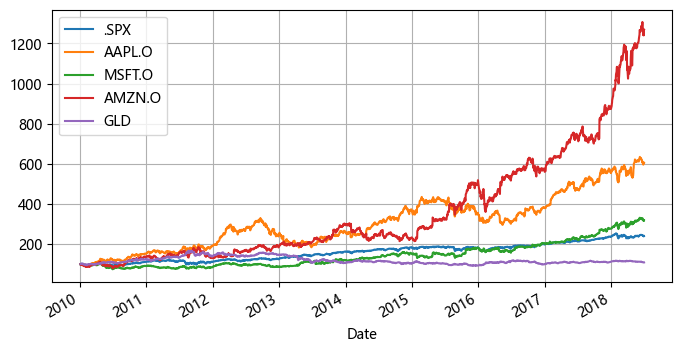

In [7]:
sel = [".SPX", "AAPL.O", "MSFT.O", "AMZN.O", "GLD"]
norm = df[sel] / df[sel].iloc[0] * 100   # 起点=100
norm.plot(figsize=(8, 4), grid=True)

## 2. 收益率：金融数据的"通用语言"

### 2.1 简单收益率 vs 对数收益率

- 简单收益率：`(今日-昨日)/昨日`
- 对数收益率：`ln(今日/昨日)`，可以直接加总，统计建模更友好

In [8]:
simple = df["SPY"].pct_change()          # (今日-昨日)/昨日
logret = np.log(df["SPY"] / df["SPY"].shift(1))
logret.head()

Date
2010-01-04         NaN
2010-01-05    0.002644
2010-01-06    0.000704
2010-01-07    0.004212
2010-01-08    0.003322
Name: SPY, dtype: float64

In [9]:
rets = np.log(df / df.shift(1))   # 12列一次全算
rets.describe().round(4)          # 每列的统计摘要

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
count,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000,2137.0000
mean,0.0008,0.0005,0.0004,0.0012,0.0001,0.0004,0.0004,-0.0001,-0.0001,0.0001,-0.0004,0.0000
std,0.0159,0.0142,0.0149,0.0195,0.0166,0.0093,0.0094,0.0774,0.0059,0.0101,0.0237,0.0102
min,-0.1319,-0.1210,-0.0954,-0.1353,-0.1369,-0.0673,-0.0690,-0.3506,-0.0265,-0.0888,-0.1139,-0.0919
25%,-0.0069,-0.0068,-0.0078,-0.0083,-0.0083,-0.0034,-0.0033,-0.0419,-0.0036,-0.0050,-0.0136,-0.0051
50%,0.0007,0.0003,0.0006,0.0010,0.0004,0.0006,0.0006,-0.0052,0.0001,0.0002,-0.0002,0.0003
75%,0.0096,0.0079,0.0084,0.0116,0.0090,0.0051,0.0050,0.0352,0.0033,0.0054,0.0130,0.0053
max,0.0850,0.0994,0.1003,0.1462,0.0905,0.0455,0.0463,0.7682,0.0304,0.0469,0.1065,0.0480


### 2.2 年化：从日到年

- 年化均值 ≈ 日均值 × 252
- 年化波动率 = 日波动率 × √252（方差按时间线性累加，标准差按平方根累加）

252 是一年的交易日数，金融计算的常用常数。

In [10]:
rets.mean() * 252                # 年化平均收益

AAPL.O    0.212359
MSFT.O    0.136648
INTC.O    0.102288
AMZN.O    0.299661
GS.N      0.028592
SPY       0.102928
.SPX      0.103202
.VIX     -0.025888
EUR=     -0.024747
XAU=      0.013162
GDX      -0.089633
GLD       0.009141
dtype: float64

In [11]:
rets.std() * np.sqrt(252)        # 年化波动率

AAPL.O    0.252533
MSFT.O    0.225647
INTC.O    0.236675
AMZN.O    0.308968
GS.N      0.263662
SPY       0.148118
.SPX      0.148509
.VIX      1.228048
EUR=      0.094151
XAU=      0.160739
GDX       0.376898
GLD       0.161891
dtype: float64

### 2.3 重采样：日频 → 月频/年频

价格取 `last`，对数收益取 `sum`——语义不同，别混用。

In [12]:
df.resample("ME").last()     # 每月最后一个交易日的价格

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-31,27.437544,28.1800,19.40,125.41,148.72,107.3900,1073.87,24.62,1.3862,1081.05,40.72,105.960
2010-02-28,29.231399,28.6700,20.53,118.40,156.35,110.7400,1104.49,19.50,1.3625,1116.10,43.89,109.430
2010-03-31,33.571395,29.2875,22.29,135.77,170.63,117.0000,1169.43,17.59,1.3510,1112.80,44.41,108.950
2010-04-30,37.298534,30.5350,22.84,137.10,145.20,118.8125,1186.69,22.05,1.3295,1178.25,50.51,115.360
2010-05-31,36.697106,25.8000,21.42,125.46,144.26,109.3690,1089.41,32.07,1.2267,1213.81,49.86,118.881
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-28,178.120000,93.7700,49.29,1512.45,262.93,271.6500,2713.83,19.85,1.2193,1317.66,21.35,125.000
2018-03-31,167.780000,91.2700,52.08,1447.34,251.86,263.1500,2640.87,19.97,1.2301,1324.00,21.98,125.790
2018-04-30,165.260000,93.5200,51.62,1566.13,238.33,264.5100,2648.05,15.93,1.2077,1314.95,22.28,124.590


In [13]:
rets.resample("ME").sum()    # 对数收益按月加总=月收益

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-31,-0.108199,-0.093760,-0.073519,-0.065505,-0.151689,-0.053837,-0.053591,0.205829,-0.038841,-0.035396,-0.158422,-0.035599
2010-02-28,0.063331,0.017239,0.056614,-0.057520,0.050032,0.030718,0.028115,-0.233145,-0.017245,0.031908,0.074967,0.032223
2010-03-31,0.138431,0.021310,0.082251,0.136894,0.087400,0.054989,0.057133,-0.103084,-0.008476,-0.002961,0.011778,-0.004396
2010-04-30,0.105280,0.041713,0.024375,0.009748,-0.161385,0.015373,0.014651,0.225982,-0.016042,0.057151,0.128707,0.057169
2010-05-31,-0.016256,-0.168499,-0.064188,-0.088724,-0.006495,-0.082819,-0.085532,0.374608,-0.080475,0.029734,-0.012952,0.030065
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-02-28,0.061892,-0.013137,0.023608,0.041554,-0.018689,-0.037038,-0.039726,0.382556,-0.018446,-0.020314,-0.106531,-0.020978
2018-03-31,-0.059804,-0.027023,0.055060,-0.044003,-0.043014,-0.031790,-0.027253,0.006027,0.008819,0.004800,0.029081,0.006300
2018-04-30,-0.015134,0.024353,-0.008872,0.078880,-0.055217,0.005155,0.002715,-0.226027,-0.018378,-0.006859,0.013556,-0.009586


## 3. 滚动统计与波动率聚集

`rolling(n)`：每次取最近 n 个数据算统计量，窗口逐日滑动。
前 n-1 个结果为 `NaN`——数据不足，正常现象。

In [14]:
spy = rets["SPY"].dropna()
ma21  = spy.rolling(21).mean()   # 21日移动平均
vol21 = spy.rolling(21).std() * np.sqrt(252)  # 滚动年化波动率
vol21.head(25)    # 前20个是NaN：窗口不足

Date
2010-01-05         NaN
2010-01-06         NaN
2010-01-07         NaN
2010-01-08         NaN
2010-01-11         NaN
2010-01-12         NaN
2010-01-13         NaN
2010-01-14         NaN
2010-01-15         NaN
2010-01-19         NaN
2010-01-20         NaN
2010-01-21         NaN
2010-01-22         NaN
2010-01-25         NaN
2010-01-26         NaN
2010-01-27         NaN
2010-01-28         NaN
2010-01-29         NaN
2010-02-01         NaN
2010-02-02         NaN
2010-02-03    0.164789
2010-02-04    0.193596
2010-02-05    0.193991
2010-02-08    0.192644
2010-02-09    0.199286
Name: SPY, dtype: float64

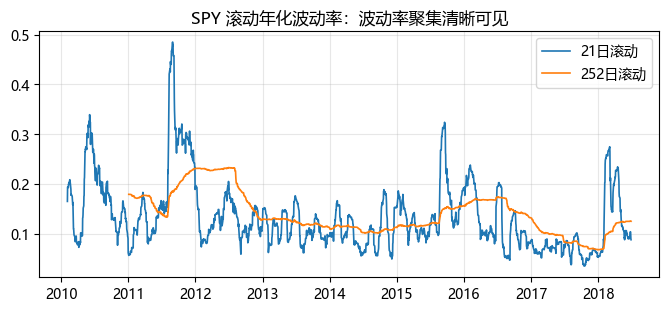

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(spy.index, vol21, label="21日滚动", linewidth=1.2)
ax.plot(spy.index, spy.rolling(252).std() * np.sqrt(252),
        label="252日滚动", linewidth=1.2)
ax.set_title("SPY 滚动年化波动率：波动率聚集清晰可见")
ax.legend()
ax.grid(alpha=0.3)

**波动率聚集**（volatility clustering）：波动率平时低，危机时突然飙升，然后缓慢回落。

实际意义：
- 风险度量（VaR）必须用**最近**的数据，而不是八年平均；
- 21日窗口反应快但噪声大，252日窗口平滑但迟钝——窗口选择是权衡。

## 4. 收益率分布与厚尾

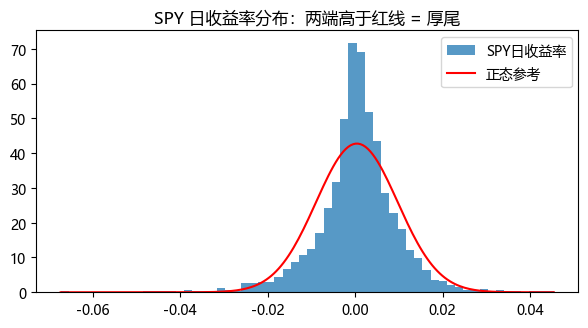

In [16]:
from scipy.stats import norm

r = rets["SPY"].dropna()
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(r, bins=60, density=True, alpha=0.75, label="SPY日收益率")
xx = np.linspace(r.min(), r.max(), 200)
ax.plot(xx, norm.pdf(xx, r.mean(), r.std()), color="red", label="正态参考")
ax.set_title("SPY 日收益率分布：两端高于红线 = 厚尾")
ax.legend()

In [17]:
(r.abs() > 0.03).sum()    # |日收益|>3%的天数：27天

np.int64(27)

按正态分布（日标准差约1%）计算，|r|>3% 几乎不可能发生（理论上不到 1 天），
实际却有 **27 天**——**厚尾**：极端行情远比正态分布预想的频繁。

## 5. 回归分析：beta 是怎么算出来的

CAPM：$r_i = \alpha + \beta \, r_m + \varepsilon$

- β=1 与市场同步；β>1 放大波动；β<1 相对稳健。
- 估计方法：把历史日收益做最小二乘回归（OLS）。

In [18]:
x = rets[".SPX"].dropna()      # 市场收益
y = rets["AAPL.O"].dropna()    # 苹果收益
beta, alpha = np.polyfit(x, y, 1)   # 一元线性拟合
round(beta, 2)

np.float64(0.96)

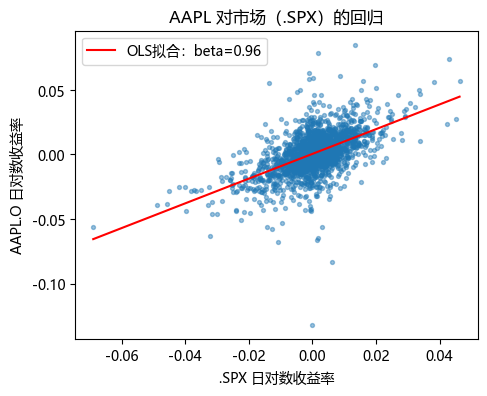

In [19]:
fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(x, y, s=8, alpha=0.45)
xx = np.linspace(x.min(), x.max(), 50)
ax.plot(xx, alpha + beta * xx, color="red", linewidth=1.5,
        label=f"OLS拟合：beta={beta:.2f}")
ax.set_xlabel(".SPX 日对数收益率")
ax.set_ylabel("AAPL.O 日对数收益率")
ax.set_title("AAPL 对市场（.SPX）的回归")
ax.legend()

**相关系数 vs 回归系数**：
- 相关系数衡量"联动紧密程度"，范围 [-1, 1]；
- beta 衡量"市场涨1%，个股平均涨多少"，可以大于1或为负。

In [20]:
x.corr(y)    # 相关系数：约0.56

np.float64(0.5630362990796212)

**换个视角：VIX 恐慌指数**——市场恐慌升高时，股价倾向下跌（负相关）。

相关系数： -0.177


Text(0.5, 1.0, '恐慌指数与市场收益')

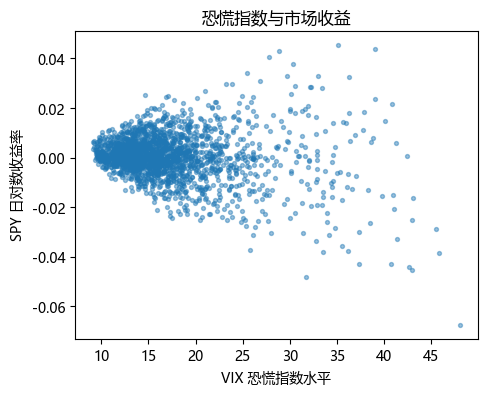

In [21]:
v = df[".VIX"].dropna()
s = rets["SPY"].dropna()
v, s = v.align(s, join="inner")
v, s = v.dropna(), s.dropna()
print("相关系数：", round(v.corr(s), 3))

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(v, s, s=8, alpha=0.45)
ax.set_xlabel("VIX 恐慌指数水平")
ax.set_ylabel("SPY 日对数收益率")
ax.set_title("恐慌指数与市场收益")

## 6. 课后练习

1. 对 MSFT.O 重复 beta 回归，比较与苹果的 beta 大小，
   并结合两家公司的业务特点给出解释。
2. 把滚动波动率窗口从 21 改为 63（一个季度），观察图形平滑程度的变化。
3. 选做：统计 |r|>5% 的天数，查一查这些日期分别对应什么历史事件。

<details>
<summary>练习1 参考答案（点击展开）</summary>

```python
y_ms = rets["MSFT.O"].dropna()
beta_ms, alpha_ms = np.polyfit(x, y_ms, 1)
print("MSFT beta:", round(beta_ms, 2))
print("AAPL beta:", round(beta, 2))
```

</details>

<details>
<summary>练习2 参考答案（点击展开）</summary>

```python
vol63 = spy.rolling(63).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(spy.index, vol21, label="21日", linewidth=0.9, alpha=0.7)
ax.plot(spy.index, vol63, label="63日", linewidth=1.3)
ax.set_title("滚动年化波动率：窗口越长越平滑")
ax.legend()
ax.grid(alpha=0.3)
```

</details>

<details>
<summary>练习3 参考答案（点击展开）</summary>

```python
extreme = r[r.abs() > 0.05]
print(extreme.sort_values())   # 按跌幅排序，对照财经日历查事件
```

</details>